In [24]:
import numpy as np
from scipy.optimize import root_scalar
import xraylib
import matplotlib.pyplot as plt
import epics
import time


In [4]:
# Beamline input block
energy = 15000.0            # Energy in eV
energy_keV = energy/1000.0  # Energy in keV
wl = 1239.84 / (energy * 10**9)
d_StoL1 = 51.9              # Source-to-CRL1 distance, in m
d_StoL2 = 62.1              # Source-to-CRL2 distance, in m
d_Stof  = 66.2              # Source-to-focus distance, in m

#slit1_H = 500.0e-6          # H slit size before CRL 1
#slit1_V = 300.0e-6          # V slit size before CRL 1
#slit2_H = 500.0e-6          # H slit size before CRL 2
#slit2_V = 300.0e-6          # V slit size before CRL 2

In [5]:
# CRL input block
d_min   = 3.0e-5            # Minimum thickness at the apex in m
stack_d = 50.0e-3           # Stack thickness in m
L1_n    = np.array([1,      1,      1,      1,      1,      1,      2,      4,      8,      16])                # CRL1 number of lenses in each stack
L1_R    = np.array([2.0e-3, 1.0e-3, 5.0e-4, 3.0e-4, 2.0e-4, 1.0e-4, 1.0e-4, 1.0e-4, 1.0e-4, 1.0e-4])            # CRL1 lens radius in each stack
L1_mater= np.array(["Be",   "Be",   "Be",   "Be",   "Be",   "Be",   "Be",   "Be",   "Be",   "Be"])              # CRL1 lens material in each stack
L1_loc  = np.array([4.5,    3.5,    2.5,    1.5,    0.5,    -0.5,   -1.5,   -2.5,   -3.5,   -4.5])*stack_d      # CRL1 lens stack location relative to center stack, positive means upstream
L1_HE   = np.array([1.0e-6, 1.0e-6, 1.0e-6, 1.0e-6, 1.0e-6, 1.0e-6, 1.4e-6, 2.0e-6, 2.8e-6, 4.0e-6])            # CRL1 lens RMS thickness error
L2_n    = np.array([1,      1,      1,      1,      1,      1,      2,      4,      8,      16])                # CRL2 number of lenses in each stack
L2_R    = np.array([2.0e-3, 1.0e-3, 5.0e-4, 3.0e-4, 2.0e-4, 1.0e-4, 1.0e-4, 1.0e-4, 1.0e-4, 1.0e-4])            # CRL2 lens radius in each stack
L2_mater= np.array(["Be",   "Be",   "Be",   "Be",   "Be",   "Be",   "Be",   "Be",   "Be",   "Be"])              # CRL2 lens material in each stack
L2_loc  = np.array([4.5,    3.5,    2.5,    1.5,    0.5,    -0.5,   -1.5,   -2.5,   -3.5,   -4.5])*stack_d      # CRL2 lens stack location relative to center stack, positive means upstream
L2_HE   = np.array([1.0e-6, 1.0e-6, 1.0e-6, 1.0e-6, 1.0e-6, 1.0e-6, 1.4e-6, 2.0e-6, 2.8e-6, 4.0e-6])           # CRL2 lens RMS thickness error


In [6]:
# Source size input block
L_und = 4.7                 # undulator length
sigmaH_e = 14.8e-6          # Sigma electron source size in H direction in m
sigmaV_e = 3.7e-6           # Sigma electron source size in V direction in m
sigmaHp_e = 2.8e-6          # Sigma electron divergence in H direction in rad
sigmaVp_e = 1.5e-6          # Sigma electron divergence in V direction in rad
sigmaH = (sigmaH_e**2 + wl*L_und/2/np.pi/np.pi)**0.5
sigmaV = (sigmaV_e**2 + wl*L_und/2/np.pi/np.pi)**0.5
sigmaHp = (sigmaHp_e**2 + wl/L_und/2)**0.5
sigmaVp = (sigmaVp_e**2 + wl/L_und/2)**0.5


In [7]:
# Lookup table where each entry is a tuple (column1, column2)
Lens_diameter_table = [
    (50, 450.0),
    (100, 632.0),
    (200, 894.0),
    (300, 1095.0),
    (500, 1414.0),
    (1000, 2000.0),
    (1500, 2450.0),
]

# Convert the lookup table to a dictionary for faster lookup
Lens_diameter_dict = {int(col1): col2 for col1, col2 in Lens_diameter_table}

def lookup_diameter(lens_radius):
    # Convert the input float to an integer
    input_int = int(round(lens_radius*1.0e6))
    return Lens_diameter_dict.get(input_int, (lens_radius*1.0e6)**0.5*63.222+ 0.73)/1.0e6


In [8]:
def index_to_binary_list(index, length):
    """
    Converts an index number to its binary representation as a list of digits,
    and pads the list with zeros in front to achieve the desired length.

    Parameters:
        index (int): The index number to be converted.
        length (int): The desired length of the binary list.

    Returns:
        list: A list of digits representing the binary representation of the index.
    """
    # Convert the index to a binary string and remove the '0b' prefix
    binary_str = bin(index)[2:]

    # Pad the binary string with zeros in front to achieve the desired length
    #padded_binary_str = binary_str.zfill(length)

    # Reverse the binary string
    reversed_binary_str = binary_str[::-1]

    # Convert the reversed binary string to a list of integers
    binary_list = [int(digit) for digit in reversed_binary_str]

    # Pad the list with zeros at the end to achieve the desired length
    while len(binary_list) < length:
        binary_list.append(0)
    return binary_list

In [9]:
def binary_list_to_index(binary_list, length):
    """
    Converts a list of binary digits in reverse order to its integer representation,
    padding the list with zeros at the end to have a fixed number of elements.

    Parameters:
        binary_list (list): A list of digits representing the binary number in reverse order.
        length (int): The fixed number of elements the list should have.

    Returns:
        int: The integer representation of the binary number.
    """
    # Pad the list with zeros at the end to achieve the desired length
    while len(binary_list) < length:
        binary_list.append(0)

    # Convert the binary list to an integer
    index = 0
    for i, digit in enumerate(binary_list):
        index += digit * 2**i

    return index

In [10]:
def materials_to_deltas(material_list, energy):
    """
    Convert a list of material names to a list of delta values at a given energy.

    Parameters:
        material_list (list): A list of material names.
        energy (float): The energy in keV.

    Returns:
        list: A list of delta values for the given materials at the given energy.
    """
    # The list to store delta values
    delta_list = []

    # Iterate through each material in the input list
    for material in material_list:
        # Compute the delta value for the current material at the given energy
        Z = xraylib.SymbolToAtomicNumber(material)
        density = xraylib.ElementDensity(Z)
        delta = 1.0-xraylib.Refractive_Index_Re(material, energy, density)

        # Add the delta value to the delta list
        delta_list.append(delta)

    return delta_list

In [11]:
def materials_to_linear_attenuation(material_list, energy):
    """
    Convert a list of material names to a list of linear attenuation coefficients at a given energy.

    Parameters:
        material_list (list): A list of material names.
        energy (float): The energy in keV.

    Returns:
        list: A list of linear attenuation coefficient values (in m^-1) for the given materials at the given energy.
    """
    # The list to store linear attenuation coefficient values
    mu_list = []

    # Iterate through each material in the input list
    for material in material_list:
        # Compute the delta value for the current material at the given energy
        Z = xraylib.SymbolToAtomicNumber(material)
        density = xraylib.ElementDensity(Z)
        # Compute the mass attenuation coefficient in cm^2/g
        #mass_attenuation = xraylib.CS_Photo(Z, energy)
        mass_attenuation = xraylib.CS_Total(Z, energy)
        # Convert mass attenuation coefficient to linear attenuation coefficient in m^-1
        mu = mass_attenuation * density * 100.0
        # Add the linear attenuation coefficient value to the list
        mu_list.append(mu)

    return mu_list


In [12]:
def absorptionaperture(x, n1mud, sigma, n1mur):
    numerator = np.exp(-(x**2/(2*sigma**2))) * np.exp(-n1mur*(x**2) - n1mud)
    denominator = np.exp(-n1mud)
    return numerator / denominator - 0.5

In [13]:
def find_levels(array, levels, direction='forward'):
    """
    Find the first indices at which the array crosses specified levels and the corresponding crossed values.

    Parameters:
        array (numpy.ndarray): An array of numbers.
        levels (float or numpy.ndarray): A number or an array of levels to find crossings.
        direction (str, optional): The searching direction. Defaults to 'forward'.
                                   Can be either 'forward' or 'backward'.

    Returns:
        tuple: A tuple containing two arrays:
            - An array of first indices at which the array crosses the specified levels.
            - An array of first crossed values at the corresponding indices.
    """

    # Convert a single level to a numpy array
    if isinstance(levels, (int, float)):
        levels = np.array([levels])

    indices = []
    values = []

    # Compute the max and min of the array ignoring NaNs
    max_val = np.nanmax(array)
    min_val = np.nanmin(array)

    for level in levels:
        # If level is out of bounds
        if level > max_val or level < min_val:
            indices.append(-1)
            values.append(np.nan)
            continue

        crossings = []

        if direction == 'forward':
            for i in range(1, len(array)):
                if np.isnan(array[i - 1]) or np.isnan(array[i]):
                    continue
                if (array[i - 1] < level <= array[i]) or (array[i - 1] > level >= array[i]):
                    crossings.append(i - 1)
                    break
        elif direction == 'backward':
            for i in range(len(array) - 2, -1, -1):
                if np.isnan(array[i + 1]) or np.isnan(array[i]):
                    continue
                if (array[i + 1] < level <= array[i]) or (array[i + 1] > level >= array[i]):
                    crossings.append(i)
                    break
        else:
            raise ValueError("Invalid direction. It should be either 'forward' or 'backward'.")

        if len(crossings) > 0:
            idx = crossings[0]
            indices.append(idx)
            values.append(array[idx])
        else:
            # In case no crossing is found within the range
            indices.append(-1)
            values.append(np.nan)

    return np.array(indices), np.array(values)

In [14]:
def Zoom_CRL2D_control(fsize):

    L1_D        = np.zeros(L1_R.size)                                   # CRL1 diameters for each stack
    for i in range(L1_R.size):
        L1_D[i] = lookup_diameter(L1_R[i])
    L1_delta    = materials_to_deltas(L1_mater, energy_keV)             # delta values for CRL1 stacks
    L1_mu       = materials_to_linear_attenuation(L1_mater, energy_keV) # mu values for CRL1 stacks
    L1_Feq      = L1_R/(2*L1_n*L1_delta)+L1_loc                         # CRL1 equivalent f in m for each stack

    L2_D        = np.zeros(L2_R.size)                                   # CRL2 diameters for each stack
    for i in range(L2_R.size):
        L2_D[i] = lookup_diameter(L2_R[i])
    L2_delta    = materials_to_deltas(L2_mater, energy_keV)             # Delta values for CRL2 stacks
    L2_mu       = materials_to_linear_attenuation(L2_mater, energy_keV) # mu values for CRL2 stacks
    L2_Feq      = L2_R/(2*L2_n*L2_delta)+L2_loc                         # CRL2 equivalent f in m for each stack

    L1_index_n   = 2**L1_Feq.size                                       # Total number of combinations for CRL1
    L1_invF_list = np.zeros(L1_index_n)                                 # List of equivalent 1/f in m^-1 for CRL1
    for i in range(L1_index_n):
        L1_invF_list[i] = np.sum(index_to_binary_list(i, L1_Feq.size)/L1_Feq)
    # Sort the L1_invF list (to avoid zigzagging)
    L1_invF_list_sort_indices = np.argsort(L1_invF_list)
    L1_invF_list_sorted       = L1_invF_list[L1_invF_list_sort_indices]

    q1_list = 1/(L1_invF_list_sorted - 1/d_StoL1)                      # focal position of CRL1 for all configurations (sorted)
    # may be limit to cases q1 beyond sample???

    L2_index_n   = 2**L2_Feq.size                               # Total number of combinations for CRL2
    L2_invF_list = np.zeros(L2_index_n)                         # List of equivalent 1/f in m^-1 for CRL2
    for i in range(L2_index_n):
        L2_invF_list[i] = np.sum(index_to_binary_list(i, L2_Feq.size)/L2_Feq)
    # Sort the L2_invF list (to avoid zigzagging)
    L2_invF_list_sort_indices = np.argsort(L2_invF_list)
    L2_invF_list_sorted       = L2_invF_list[L2_invF_list_sort_indices]

    # Start generating focal size list as a function of CRL1 setting
    sigma1H         = (sigmaH**2 + (sigmaHp*d_StoL1)**2)**0.5   # sigma beam size before CRL1
    sigma1V         = (sigmaV**2 + (sigmaVp*d_StoL1)**2)**0.5   # sigma beam size before CRL1
    L1_n1mud_list   = np.zeros(L1_index_n)                      # List of n1*mu*d_min for all possible CRL1 configurations
    L1_n1muR_list   = np.zeros(L1_index_n)                      # List of n1*mu/R for all possible CRL1 configurations
    aperL1H_list    = np.zeros(L1_index_n)                      # absorption H aperture of CRL1 for all configurations
    aperL1V_list    = np.zeros(L1_index_n)                      # absorption V aperture of CRL1 for all configurations
    diameter1_list  = np.zeros(L1_index_n)                      # CRL1 diameter for all possible configurations
    FWHM1H_list     = np.zeros(L1_index_n)                      # H focal size at the focus of CRL1
    FWHM1V_list     = np.zeros(L1_index_n)                      # V focal size at the focus of CRL1
    sigma2H_list    = np.zeros(L1_index_n)                      # sigma beam size before CRL2
    sigma2V_list    = np.zeros(L1_index_n)                      # sigma beam size before CRL2
    Strehl1_list    = np.zeros(L1_index_n)                     # Strehl ratio based on lens thickness error

    for i in range(L1_index_n):
        # absorption aperture is a function of CRL absorption/physical aperture, incident beam size, and physical slits
        L1_n1mud_list[i] = np.sum(index_to_binary_list(L1_invF_list_sort_indices[i], L1_Feq.size)*np.array(L1_mu*L1_n*d_min))
        L1_n1muR_list[i] = np.sum(index_to_binary_list(L1_invF_list_sort_indices[i], L1_Feq.size)*np.array(L1_mu*L1_n/L1_R))
        solution         = root_scalar(absorptionaperture, args=(L1_n1mud_list[i], sigma1H, L1_n1muR_list[i]), bracket=[0.0, 2*sigma1H], method='bisect')
        aperL1H_list[i]  = solution.root*2.0
        solution         = root_scalar(absorptionaperture, args=(L1_n1mud_list[i], sigma1V, L1_n1muR_list[i]), bracket=[0.0, 2*sigma1V], method='bisect')
        aperL1V_list[i]  = solution.root*2.0
        mask = (np.array(index_to_binary_list(L1_invF_list_sort_indices[i], L1_Feq.size)) == 1)
        if np.all(mask == False):
            diameter1_list[i] = np.inf
        else:
            diameter1_list[i] = np.min(L1_D[mask])
        aperL1H_list[i] = min(aperL1H_list[i], diameter1_list[i], slit1_H)
        aperL1V_list[i] = min(aperL1V_list[i], diameter1_list[i], slit1_V)
        phase_error_tmp = np.linalg.norm(index_to_binary_list(L1_invF_list_sort_indices[i], L1_Feq.size)*np.array(L1_HE*L1_delta)*2*np.pi/wl)   # RMS phase error of the lens stack
        Strehl1_list[i] = np.exp(-phase_error_tmp**2)

    # FWHMbeam size at CRL1 focus
    FWHM1H_list  = ((0.88*wl*q1_list/aperL1H_list)**2 + (2.355*sigmaH*q1_list/d_StoL1)**2)**0.5
    FWHM1V_list  = ((0.88*wl*q1_list/aperL1V_list)**2 + (2.355*sigmaV*q1_list/d_StoL1)**2)**0.5
    if flag_HE:
        FWHM1H_list *= (Strehl1_list)**(-0.5)
        FWHM1V_list *= (Strehl1_list)**(-0.5)
    # Sigma beam size before CRL2
    sigma2H_list = (((0.88*wl*(d_StoL2-d_StoL1))/aperL1H_list)**2 + (aperL1H_list*(1-(d_StoL2-d_StoL1)/q1_list))**2)**0.5/2.355
    sigma2V_list = (((0.88*wl*(d_StoL2-d_StoL1))/aperL1V_list)**2 + (aperL1V_list*(1-(d_StoL2-d_StoL1)/q1_list))**2)**0.5/2.355

    p2_list      = d_StoL2 - d_StoL1 - q1_list           # p2 for CRL2 for all possible CRL1 configurations
    invf2_list   = 1.0/p2_list + 1/(d_Stof - d_StoL2)    # f2^-1 for CRL2 to match CRL1 for all possible CRL1 configurations
    #L2_config_index   = np.zeros(L1_index_n)            # CRL2 configueration index to match CRL1

    #invf2_indices, invf2_values = find_closest_values_auto(L2_invF_list_sorted, invf2_list)
    #invf2_indices, invf2_values = find_levels_left(L2_invF_list_sorted, invf2_list)
    invf2_indices, invf2_values = find_levels(L2_invF_list_sorted, invf2_list, direction = 'forward')

    nan_positions = np.where(invf2_indices == -1)
    invf2_values[nan_positions] = np.nan                # only f2^-1 values that can be matched with CRL1
    q2_list  = 1/(invf2_values - 1/p2_list)
    dq2_list = q2_list - (d_Stof - d_StoL2)

    L2_n2mud_list   = np.zeros(L1_index_n)              # List of n2*mu*d_min for all possible CRL1 configurations
    L2_n2muR_list   = np.zeros(L1_index_n)              # List of n2*mu/R for all possible CRL1 configurations
    aperL2H_list    = np.zeros(L1_index_n)              # absorption H aperture of CRL2 for all CRL1 configurations
    aperL2V_list    = np.zeros(L1_index_n)              # absorption V aperture of CRL2 for all CRL1 configurations
    diameter2_list  = np.zeros(L1_index_n)              # CRL2 diameter for all possible CRL1 configurations
    FWHM2H_list     = np.zeros(L1_index_n)              # H focal size at the focus of CRL2 matching all possible CRL1 configurations
    FWHM2V_list     = np.zeros(L1_index_n)              # V focal size at the focus of CRL2 matching all possible CRL1 configurations
    FWHM_list       = np.zeros(L1_index_n)              # Focal size sqrt(H*V) at the focus of CRL2 matching all possible CRL1 configurations
    Strehl2_list     = np.zeros(L1_index_n)                      # Strehl ratio based on lens thickness error

    for i in range(L1_index_n):
        if invf2_indices[i] != -1:
            # absorption aperture is a function of CRL absorption/physical aperture, incident beam size, and physical slits
            L2_n2mud_list[i] = np.sum(index_to_binary_list(L2_invF_list_sort_indices[invf2_indices[i]], L2_Feq.size)*np.array(L2_mu*L2_n*d_min))
            L2_n2muR_list[i] = np.sum(index_to_binary_list(L2_invF_list_sort_indices[invf2_indices[i]], L2_Feq.size)*np.array(L2_mu*L2_n/L2_R))
            solution = root_scalar(absorptionaperture, args=(L2_n2mud_list[i], sigma2H_list[i], L2_n2muR_list[i]), bracket=[0.0, 2*sigma2H_list[i]], method='bisect')
            aperL2H_list[i] = solution.root*2.0
            solution = root_scalar(absorptionaperture, args=(L2_n2mud_list[i], sigma2V_list[i], L2_n2muR_list[i]), bracket=[0.0, 2*sigma2V_list[i]], method='bisect')
            aperL2V_list[i] = solution.root*2.0
            mask = (np.array(index_to_binary_list(L2_invF_list_sort_indices[invf2_indices[i]], L2_Feq.size)) == 1)
            if np.all(mask == False):
                diameter2_list[i] = np.inf
            else:
                diameter2_list[i] = np.min(L2_D[mask])
            aperL2H_list[i] = min(aperL2H_list[i], diameter2_list[i], slit2_H)
            aperL2V_list[i] = min(aperL2V_list[i], diameter2_list[i], slit2_V)
            phase_error_tmp = np.linalg.norm(index_to_binary_list(L2_invF_list_sort_indices[invf2_indices[i]], L2_Feq.size)*np.array(L2_HE*L2_delta)*2*np.pi/wl)
            Strehl2_list[i] = np.exp(-phase_error_tmp**2)
    aperL2H_list[nan_positions] = np.nan
    aperL2V_list[nan_positions] = np.nan
    Strehl2_list[nan_positions] = np.nan

    # FWHMbeam size at focus
    FWHM2H_list = ((0.88*wl*q2_list/aperL2H_list)**2 + (FWHM1H_list*q2_list/p2_list)**2)**0.5
    FWHM2V_list = ((0.88*wl*q2_list/aperL2V_list)**2 + (FWHM1V_list*q2_list/p2_list)**2)**0.5
    if flag_HE:
        FWHM2H_list *= (Strehl2_list)**(-0.5)
        FWHM2V_list *= (Strehl2_list)**(-0.5)
    FWHM_list   = (FWHM2H_list*FWHM2V_list)**0.5

    #index, value = find_closest_values_auto(FWHM_list, fsize)
    #indices, values = find_levels_left(FWHM_list, fsize)
    indices, values = find_levels(FWHM_list, fsize, direction = 'forward')
    index = indices[0]
    if index == -1:
        print(f"Cannot achieve the focal size {fsize*1.0e6:.2f} μm")
        return

    # Print results
    print("======== Find size at focus ========================================")
    print(f"Energy: {energy_keV} keV")
    print(f"CRL1 configuration index in sorted list is {index}")
    print(f"CRL1 configuration index is {L1_invF_list_sort_indices[index]} or {index_to_binary_list(L1_invF_list_sort_indices[index], L1_Feq.size)}")
    print(f"CRL1 f is {1/L1_invF_list_sorted[index]:.2f} m, focus at q1 = {q1_list[index]:.2f} m ({q1_list[index]-(d_Stof-d_StoL1):.2f} m from sample)")
    #print(f"CRL1 f is {1/L1_invF_list[L1_invF_list_sort_indices[index]]} m")
    print(f"CRL2 configuration index in sorted list is {invf2_indices[index]}")
    print(f"CRL2 configuration index is {L2_invF_list_sort_indices[invf2_indices[index]]} or {index_to_binary_list(L2_invF_list_sort_indices[invf2_indices[index]], L2_Feq.size)}")
    print(f"CRL2 f is {1/invf2_values[index]:.2f} m")
    print(f"Focal size is {FWHM2H_list[index]*1.0e6:.2f} μm x {FWHM2V_list[index]*1.0e6:.2f} μm at the focal point ({dq2_list[index]*1e3:.1f} mm from sample)")

    FWHM2H_atsample_list = (FWHM2H_list**2 + (aperL2H_list*dq2_list/q2_list)**2)**0.5
    FWHM2V_atsample_list = (FWHM2V_list**2 + (aperL2V_list*dq2_list/q2_list)**2)**0.5
    FWHM_atsample_list   = (FWHM2H_atsample_list*FWHM2V_atsample_list)**0.5
    #indices, values = find_levels_left(FWHM_atsample_list, fsize)
    indices, values = find_levels(FWHM_atsample_list, fsize, direction = 'forward')
    index2 = indices[0]
    if index2 == -1:
        print(f"Cannot achieve the bame size {fsize*1.0e6:.2f} μm at sample")
        return
    print("======== Find size at sample =======================================")
    print(f"CRL1 configuration index in sorted list is {index2}")
    print(f"CRL1 configuration index is {L1_invF_list_sort_indices[index2]} or {index_to_binary_list(L1_invF_list_sort_indices[index2], L1_Feq.size)}")
    print(f"CRL1 f is {1/L1_invF_list_sorted[index2]:.2f} m, focus at q1 = {q1_list[index2]:.2f} m ({q1_list[index2]-(d_Stof-d_StoL1):.2f} m from sample)")
    print(f"CRL2 configuration index in sorted list is {invf2_indices[index2]}")
    print(f"CRL2 configuration index is {L2_invF_list_sort_indices[invf2_indices[index2]]} or {index_to_binary_list(L2_invF_list_sort_indices[invf2_indices[index2]], L2_Feq.size)}")
    print(f"CRL2 f is {1/invf2_values[index2]:.2f} m")
    print(f"Beam size is {FWHM2H_atsample_list[index2]*1.0e6:.2f} μm x {FWHM2V_atsample_list[index2]*1.0e6:.2f} μm at the sample position)")

    return

In [43]:
def Zoom_CRL2D_focuscal(index1, index2):
    # Preparation block
    L1_D        = np.zeros(L1_R.size)                                   # CRL1 diameters for each stack
    for i in range(L1_R.size):
        L1_D[i] = lookup_diameter(L1_R[i])
    L1_delta    = materials_to_deltas(L1_mater, energy_keV)             # delta values for CRL1 stacks
    L1_mu       = materials_to_linear_attenuation(L1_mater, energy_keV) # mu values for CRL1 stacks
    L1_Feq      = L1_R/(2*L1_n*L1_delta) + L1_loc                       # CRL1 equivalent f in m for each stack
    L2_D        = np.zeros(L2_R.size)                                   # CRL2 diameters for each stack
    for i in range(L2_R.size):
        L2_D[i] = lookup_diameter(L2_R[i])
    L2_delta    = materials_to_deltas(L2_mater, energy_keV)             # Delta values for CRL2 stacks
    L2_mu       = materials_to_linear_attenuation(L2_mater, energy_keV) # mu values for CRL2 stacks
    L2_Feq      = L2_R/(2*L2_n*L2_delta) + L2_loc                       # CRL2 equivalent f in m for each stack

    # Calculation block
    L1_invF = np.sum(index_to_binary_list(index1, L1_Feq.size)/L1_Feq)  # f^-1 for CRL1
    L2_invF = np.sum(index_to_binary_list(index2, L2_Feq.size)/L2_Feq)  # f^-1 for CRL1
    q1      = 1/(L1_invF - 1/d_StoL1)                                   # focal position of CRL1
    sigma1H = (sigmaH**2 + (sigmaHp*d_StoL1)**2)**0.5                   # sigma beam size before CRL1
    sigma1V = (sigmaV**2 + (sigmaVp*d_StoL1)**2)**0.5                   # sigma beam size before CRL1

    # absorption aperture is a function of CRL absorption/physical aperture, incident beam size, and physical slits
    L1_n1mud = np.sum(index_to_binary_list(index1, L1_Feq.size)*np.array(L1_mu*L1_n*d_min))
    L1_n1muR = np.sum(index_to_binary_list(index1, L1_Feq.size)*np.array(L1_mu*L1_n/L1_R))
    solution = root_scalar(absorptionaperture, args=(L1_n1mud, sigma1H, L1_n1muR), bracket=[0.0, 2*sigma1H], method='bisect')
    aperL1H  = solution.root*2.0
    solution = root_scalar(absorptionaperture, args=(L1_n1mud, sigma1V, L1_n1muR), bracket=[0.0, 2*sigma1V], method='bisect')
    aperL1V  = solution.root*2.0
    mask     = (np.array(index_to_binary_list(index1, L1_Feq.size)) == 1)
    if np.all(mask == False):
        diameter1 = np.inf
    else:
        diameter1 = np.min(L1_D[mask])
    aperL1H = min(aperL1H, diameter1, slit1_H)
    aperL1V = min(aperL1V, diameter1, slit1_V)
    phase_error_tmp1 = np.linalg.norm(index_to_binary_list(index1, L1_Feq.size)*np.array(L1_HE*L1_delta)*2*np.pi/wl)
    Strehl1 = np.exp(-phase_error_tmp1**2)

    # FWHMbeam size at CRL1 focus
    FWHM1H  = ((0.88*wl*q1/aperL1H)**2 + (2.355*sigmaH*q1/d_StoL1)**2)**0.5
    FWHM1V  = ((0.88*wl*q1/aperL1V)**2 + (2.355*sigmaV*q1/d_StoL1)**2)**0.5
    if flag_HE:
        FWHM1H *= (Strehl1)**(-0.5)
        FWHM1V *= (Strehl1)**(-0.5)

    # Sigma beam size before CRL2
    sigma2H = (((0.88*wl*(d_StoL2-d_StoL1))/aperL1H)**2 + (aperL1H*(1-(d_StoL2-d_StoL1)/q1))**2)**0.5/2.355
    sigma2V = (((0.88*wl*(d_StoL2-d_StoL1))/aperL1V)**2 + (aperL1V*(1-(d_StoL2-d_StoL1)/q1))**2)**0.5/2.355

    p2      = d_StoL2 - d_StoL1 - q1    # p2 for CRL2
    q2      = 1/(L2_invF - 1/p2)        # q2 for CRL2 calculated from CRL2 index and p2
    dq2     = q2 - (d_Stof - d_StoL2)   # off focus distance

    L2_n2mud = np.sum(index_to_binary_list(index2, L2_Feq.size)*np.array(L2_mu*L2_n*d_min))
    L2_n2muR = np.sum(index_to_binary_list(index2, L2_Feq.size)*np.array(L2_mu*L2_n/L2_R))
    solution = root_scalar(absorptionaperture, args=(L2_n2mud, sigma2H, L2_n2muR), bracket=[0.0, 2*sigma2H], method='bisect')

    aperL2H = solution.root*2.0
    solution = root_scalar(absorptionaperture, args=(L2_n2mud, sigma2V, L2_n2muR), bracket=[0.0, 2*sigma2V], method='bisect')
    aperL2V = solution.root*2.0
    mask = (np.array(index_to_binary_list(index2, L2_Feq.size)) == 1)
    if np.all(mask == False):
        diameter2 = np.inf
    else:
        diameter2 = np.min(L2_D[mask])
    aperL2H = min(aperL2H, diameter2, slit2_H)
    aperL2V = min(aperL2V, diameter2, slit2_V)
    phase_error_tmp2 = np.linalg.norm(index_to_binary_list(index2, L2_Feq.size)*np.array(L2_HE*L2_delta)*2*np.pi/wl)
    Strehl2 = np.exp(-phase_error_tmp2**2)

    FWHM2H = ((0.88*wl*q2/aperL2H)**2 + (FWHM1H*q2/p2)**2)**0.5
    FWHM2V = ((0.88*wl*q2/aperL2V)**2 + (FWHM1V*q2/p2)**2)**0.5
    if flag_HE:
        FWHM2H *= (Strehl2)**(-0.5)
        FWHM2V *= (Strehl2)**(-0.5)

    FWHM2H_atsample = (FWHM2H**2 + (aperL2H*dq2/q2)**2)**0.5
    FWHM2V_atsample = (FWHM2V**2 + (aperL2V*dq2/q2)**2)**0.5

   # print("====================================================================")
   # print(f"Energy: {energy_keV} keV")
   # print(f"CRL1 configuration index is {index1} or {index_to_binary_list(index1, L1_Feq.size)}")
   # print(f"CRL1 f is {1/L1_invF:.2f} m, focus at q1 = {q1:.2f} m ({q1-(d_Stof-d_StoL1):.2f} m from sample)")
   # print(f"CRL2 configuration index is {index2} or {index_to_binary_list(index2, L2_Feq.size)}")
   # print(f"CRL2 f is {1/L2_invF:.2f} m")
   # print(f"Focal size is {FWHM2H*1.0e6:.2f} μm x {FWHM2V*1.0e6:.2f} μm at the focal point ({dq2*1e3:.1f} mm from sample)")
   # print(f"Beam size is {FWHM2H_atsample*1.0e6:.2f} μm x {FWHM2V_atsample*1.0e6:.2f} μm at sample position")

    return (FWHM2H_atsample*FWHM2V_atsample)**0.5


In [16]:
def Zoom_CRL2D_lookup():

    L1_D        = np.zeros(L1_R.size)                                   # CRL1 diameters for each stack
    for i in range(L1_R.size):
        L1_D[i] = lookup_diameter(L1_R[i])
    L1_delta    = materials_to_deltas(L1_mater, energy_keV)             # delta values for CRL1 stacks
    L1_mu       = materials_to_linear_attenuation(L1_mater, energy_keV) # mu values for CRL1 stacks
    L1_Feq      = L1_R/(2*L1_n*L1_delta)+L1_loc                         # CRL1 equivalent f in m for each stack

    L2_D        = np.zeros(L2_R.size)                                   # CRL2 diameters for each stack
    for i in range(L2_R.size):
        L2_D[i] = lookup_diameter(L2_R[i])
    L2_delta    = materials_to_deltas(L2_mater, energy_keV)             # Delta values for CRL2 stacks
    L2_mu       = materials_to_linear_attenuation(L2_mater, energy_keV) # mu values for CRL2 stacks
    L2_Feq      = L2_R/(2*L2_n*L2_delta)+L2_loc                         # CRL2 equivalent f in m for each stack

    L1_index_n   = 2**L1_Feq.size                                       # Total number of combinations for CRL1
    L1_invF_list = np.zeros(L1_index_n)                                 # List of equivalent 1/f in m^-1 for CRL1
    for i in range(L1_index_n):
        L1_invF_list[i] = np.sum(index_to_binary_list(i, L1_Feq.size)/L1_Feq)
    # Sort the L1_invF list (to avoid zigzagging)
    L1_invF_list_sort_indices = np.argsort(L1_invF_list)
    L1_invF_list_sorted       = L1_invF_list[L1_invF_list_sort_indices]

    q1_list = 1/(L1_invF_list_sorted - 1/d_StoL1)                      # focal position of CRL1 for all configurations (sorted)
    # may be limit to cases q1 beyond sample???

    L2_index_n   = 2**L2_Feq.size                               # Total number of combinations for CRL2
    L2_invF_list = np.zeros(L2_index_n)                         # List of equivalent 1/f in m^-1 for CRL2
    for i in range(L2_index_n):
        L2_invF_list[i] = np.sum(index_to_binary_list(i, L2_Feq.size)/L2_Feq)
    # Sort the L2_invF list (to avoid zigzagging)
    L2_invF_list_sort_indices = np.argsort(L2_invF_list)
    L2_invF_list_sorted       = L2_invF_list[L2_invF_list_sort_indices]

    # Start generating focal size list as a function of CRL1 setting
    sigma1H         = (sigmaH**2 + (sigmaHp*d_StoL1)**2)**0.5   # sigma beam size before CRL1
    sigma1V         = (sigmaV**2 + (sigmaVp*d_StoL1)**2)**0.5   # sigma beam size before CRL1
    L1_n1mud_list   = np.zeros(L1_index_n)                      # List of n1*mu*d_min for all possible CRL1 configurations
    L1_n1muR_list   = np.zeros(L1_index_n)                      # List of n1*mu/R for all possible CRL1 configurations
    aperL1H_list    = np.zeros(L1_index_n)                      # absorption H aperture of CRL1 for all configurations
    aperL1V_list    = np.zeros(L1_index_n)                      # absorption V aperture of CRL1 for all configurations
    diameter1_list  = np.zeros(L1_index_n)                      # CRL1 diameter for all possible configurations
    FWHM1H_list     = np.zeros(L1_index_n)                      # H focal size at the focus of CRL1
    FWHM1V_list     = np.zeros(L1_index_n)                      # V focal size at the focus of CRL1
    sigma2H_list    = np.zeros(L1_index_n)                      # sigma beam size before CRL2
    sigma2V_list    = np.zeros(L1_index_n)                      # sigma beam size before CRL2
    Strehl1_list    = np.zeros(L1_index_n)                     # Strehl ratio based on lens thickness error

    for i in range(L1_index_n):
        # absorption aperture is a function of CRL absorption/physical aperture, incident beam size, and physical slits
        L1_n1mud_list[i] = np.sum(index_to_binary_list(L1_invF_list_sort_indices[i], L1_Feq.size)*np.array(L1_mu*L1_n*d_min))
        L1_n1muR_list[i] = np.sum(index_to_binary_list(L1_invF_list_sort_indices[i], L1_Feq.size)*np.array(L1_mu*L1_n/L1_R))
        solution         = root_scalar(absorptionaperture, args=(L1_n1mud_list[i], sigma1H, L1_n1muR_list[i]), bracket=[0.0, 2*sigma1H], method='bisect')
        aperL1H_list[i]  = solution.root*2.0
        solution         = root_scalar(absorptionaperture, args=(L1_n1mud_list[i], sigma1V, L1_n1muR_list[i]), bracket=[0.0, 2*sigma1V], method='bisect')
        aperL1V_list[i]  = solution.root*2.0
        mask = (np.array(index_to_binary_list(L1_invF_list_sort_indices[i], L1_Feq.size)) == 1)
        if np.all(mask == False):
            diameter1_list[i] = np.inf
        else:
            diameter1_list[i] = np.min(L1_D[mask])
        aperL1H_list[i] = min(aperL1H_list[i], diameter1_list[i], slit1_H)
        aperL1V_list[i] = min(aperL1V_list[i], diameter1_list[i], slit1_V)
        phase_error_tmp = np.linalg.norm(index_to_binary_list(L1_invF_list_sort_indices[i], L1_Feq.size)*np.array(L1_HE*L1_delta)*2*np.pi/wl)   # RMS phase error of the lens stack
        Strehl1_list[i] = np.exp(-phase_error_tmp**2)

    # FWHMbeam size at CRL1 focus
    FWHM1H_list  = ((0.88*wl*q1_list/aperL1H_list)**2 + (2.355*sigmaH*q1_list/d_StoL1)**2)**0.5
    FWHM1V_list  = ((0.88*wl*q1_list/aperL1V_list)**2 + (2.355*sigmaV*q1_list/d_StoL1)**2)**0.5
    if flag_HE:
        FWHM1H_list *= (Strehl1_list)**(-0.5)
        FWHM1V_list *= (Strehl1_list)**(-0.5)
    # Sigma beam size before CRL2
    sigma2H_list = (((0.88*wl*(d_StoL2-d_StoL1))/aperL1H_list)**2 + (aperL1H_list*(1-(d_StoL2-d_StoL1)/q1_list))**2)**0.5/2.355
    sigma2V_list = (((0.88*wl*(d_StoL2-d_StoL1))/aperL1V_list)**2 + (aperL1V_list*(1-(d_StoL2-d_StoL1)/q1_list))**2)**0.5/2.355

    p2_list      = d_StoL2 - d_StoL1 - q1_list           # p2 for CRL2 for all possible CRL1 configurations
    invf2_list   = 1.0/p2_list + 1/(d_Stof - d_StoL2)    # f2^-1 for CRL2 to match CRL1 for all possible CRL1 configurations
    #L2_config_index   = np.zeros(L1_index_n)            # CRL2 configueration index to match CRL1

    #invf2_indices, invf2_values = find_closest_values_auto(L2_invF_list_sorted, invf2_list)
    #invf2_indices, invf2_values = find_levels_left(L2_invF_list_sorted, invf2_list)
    invf2_indices, invf2_values = find_levels(L2_invF_list_sorted, invf2_list, direction = 'forward')

    nan_positions = np.where(invf2_indices == -1)
    invf2_values[nan_positions] = np.nan                # only f2^-1 values that can be matched with CRL1
    q2_list  = 1/(invf2_values - 1/p2_list)
    dq2_list = q2_list - (d_Stof - d_StoL2)

    L2_n2mud_list   = np.zeros(L1_index_n)              # List of n2*mu*d_min for all possible CRL1 configurations
    L2_n2muR_list   = np.zeros(L1_index_n)              # List of n2*mu/R for all possible CRL1 configurations
    aperL2H_list    = np.zeros(L1_index_n)              # absorption H aperture of CRL2 for all CRL1 configurations
    aperL2V_list    = np.zeros(L1_index_n)              # absorption V aperture of CRL2 for all CRL1 configurations
    diameter2_list  = np.zeros(L1_index_n)              # CRL2 diameter for all possible CRL1 configurations
    FWHM2H_list     = np.zeros(L1_index_n)              # H focal size at the focus of CRL2 matching all possible CRL1 configurations
    FWHM2V_list     = np.zeros(L1_index_n)              # V focal size at the focus of CRL2 matching all possible CRL1 configurations
    FWHM_list       = np.zeros(L1_index_n)              # Focal size sqrt(H*V) at the focus of CRL2 matching all possible CRL1 configurations
    Strehl2_list     = np.zeros(L1_index_n)                      # Strehl ratio based on lens thickness error

    for i in range(L1_index_n):
        if invf2_indices[i] != -1:
            # absorption aperture is a function of CRL absorption/physical aperture, incident beam size, and physical slits
            L2_n2mud_list[i] = np.sum(index_to_binary_list(L2_invF_list_sort_indices[invf2_indices[i]], L2_Feq.size)*np.array(L2_mu*L2_n*d_min))
            L2_n2muR_list[i] = np.sum(index_to_binary_list(L2_invF_list_sort_indices[invf2_indices[i]], L2_Feq.size)*np.array(L2_mu*L2_n/L2_R))
            solution = root_scalar(absorptionaperture, args=(L2_n2mud_list[i], sigma2H_list[i], L2_n2muR_list[i]), bracket=[0.0, 2*sigma2H_list[i]], method='bisect')
            aperL2H_list[i] = solution.root*2.0
            solution = root_scalar(absorptionaperture, args=(L2_n2mud_list[i], sigma2V_list[i], L2_n2muR_list[i]), bracket=[0.0, 2*sigma2V_list[i]], method='bisect')
            aperL2V_list[i] = solution.root*2.0
            mask = (np.array(index_to_binary_list(L2_invF_list_sort_indices[invf2_indices[i]], L2_Feq.size)) == 1)
            if np.all(mask == False):
                diameter2_list[i] = np.inf
            else:
                diameter2_list[i] = np.min(L2_D[mask])
            aperL2H_list[i] = min(aperL2H_list[i], diameter2_list[i], slit2_H)
            aperL2V_list[i] = min(aperL2V_list[i], diameter2_list[i], slit2_V)
            phase_error_tmp = np.linalg.norm(index_to_binary_list(L2_invF_list_sort_indices[invf2_indices[i]], L2_Feq.size)*np.array(L2_HE*L2_delta)*2*np.pi/wl)
            Strehl2_list[i] = np.exp(-phase_error_tmp**2)
    aperL2H_list[nan_positions] = np.nan
    aperL2V_list[nan_positions] = np.nan
    Strehl2_list[nan_positions] = np.nan

    # FWHMbeam size at focus
    FWHM2H_list = ((0.88*wl*q2_list/aperL2H_list)**2 + (FWHM1H_list*q2_list/p2_list)**2)**0.5
    FWHM2V_list = ((0.88*wl*q2_list/aperL2V_list)**2 + (FWHM1V_list*q2_list/p2_list)**2)**0.5
    if flag_HE:
        FWHM2H_list *= (Strehl2_list)**(-0.5)
        FWHM2V_list *= (Strehl2_list)**(-0.5)
    FWHM_list   = (FWHM2H_list*FWHM2V_list)**0.5

    FWHM2H_atsample_list = (FWHM2H_list**2 + (aperL2H_list*dq2_list/q2_list)**2)**0.5
    FWHM2V_atsample_list = (FWHM2V_list**2 + (aperL2V_list*dq2_list/q2_list)**2)**0.5
    FWHM_atsample_list   = (FWHM2H_atsample_list*FWHM2V_atsample_list)**0.5

    return FWHM_atsample_list, L1_invF_list_sort_indices, invf2_indices

# Testing XS lookup table function

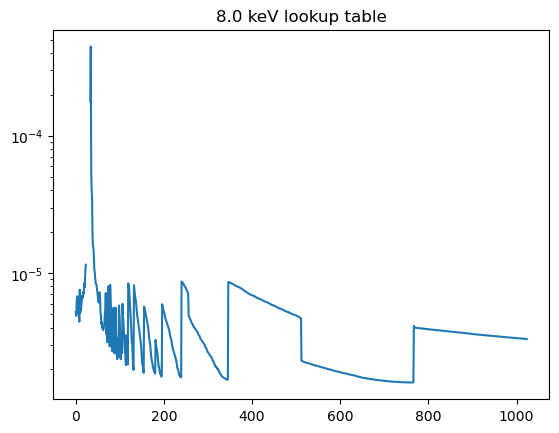

In [17]:
# Beamline input block
energy = 8000.0            # Energy in eV
energy_keV = energy/1000.0  # Energy in keV
wl = 1239.84 / (energy * 10**9)
sigmaH = (sigmaH_e**2 + wl*L_und/2/np.pi/np.pi)**0.5
sigmaV = (sigmaV_e**2 + wl*L_und/2/np.pi/np.pi)**0.5
sigmaHp = (sigmaHp_e**2 + wl/L_und/2)**0.5
sigmaVp = (sigmaVp_e**2 + wl/L_und/2)**0.5

flag_HE = True
slit1_H = 500.0e-6          # H slit size before CRL 1
slit1_V = 300.0e-6          # V slit size before CRL 1
slit2_H = 500.0e-6          # H slit size before CRL 2
slit2_V = 300.0e-6          # V slit size before CRL 2

lookup_table, L1_inF_list_sort_indices, index1to2 = Zoom_CRL2D_lookup()

plt.plot(np.linspace(0,1023,1024), lookup_table)
plt.title(str(energy_keV)+' keV lookup table')
plt.yscale('log')
plt.show()

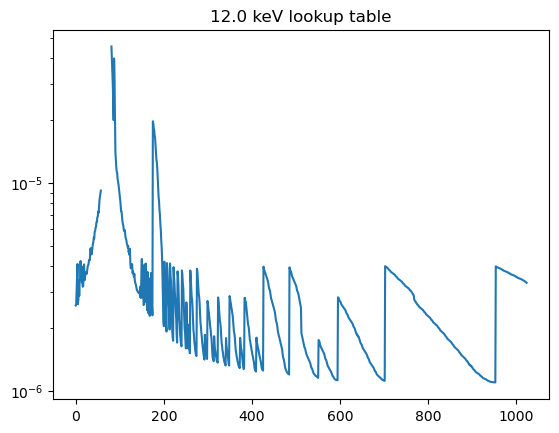

In [18]:
# Beamline input block
energy = 12000.0            # Energy in eV
energy_keV = energy/1000.0  # Energy in keV
wl = 1239.84 / (energy * 10**9)
sigmaH = (sigmaH_e**2 + wl*L_und/2/np.pi/np.pi)**0.5
sigmaV = (sigmaV_e**2 + wl*L_und/2/np.pi/np.pi)**0.5
sigmaHp = (sigmaHp_e**2 + wl/L_und/2)**0.5
sigmaVp = (sigmaVp_e**2 + wl/L_und/2)**0.5

flag_HE = True
slit1_H = 500.0e-6          # H slit size before CRL 1
slit1_V = 300.0e-6          # V slit size before CRL 1
slit2_H = 500.0e-6          # H slit size before CRL 2
slit2_V = 300.0e-6          # V slit size before CRL 2

lookup_table, L1_inF_list_sort_indices, index1to2 = Zoom_CRL2D_lookup()

plt.plot(np.linspace(0,1023,1024), lookup_table)
plt.title(str(energy_keV)+' keV lookup table')
plt.yscale('log')
plt.show()

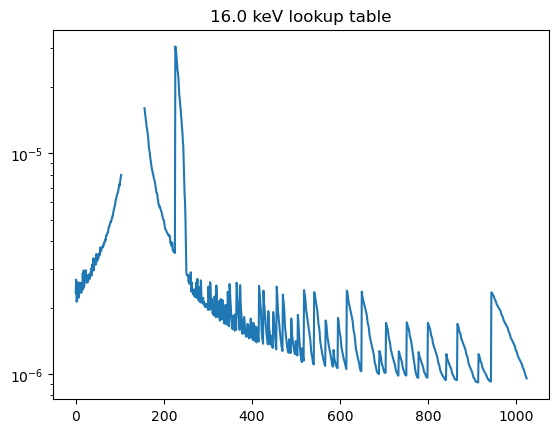

In [19]:
# Beamline input block
energy = 16000.0            # Energy in eV
energy_keV = energy/1000.0  # Energy in keV
wl = 1239.84 / (energy * 10**9)
sigmaH = (sigmaH_e**2 + wl*L_und/2/np.pi/np.pi)**0.5
sigmaV = (sigmaV_e**2 + wl*L_und/2/np.pi/np.pi)**0.5
sigmaHp = (sigmaHp_e**2 + wl/L_und/2)**0.5
sigmaVp = (sigmaVp_e**2 + wl/L_und/2)**0.5

flag_HE = True
slit1_H = 500.0e-6          # H slit size before CRL 1
slit1_V = 300.0e-6          # V slit size before CRL 1
slit2_H = 500.0e-6          # H slit size before CRL 2
slit2_V = 300.0e-6          # V slit size before CRL 2

lookup_table, L1_inF_list_sort_indices, index1to2 = Zoom_CRL2D_lookup()

plt.plot(np.linspace(0,1023,1024), lookup_table)
plt.title(str(energy_keV)+' keV lookup table')
plt.yscale('log')
plt.show()

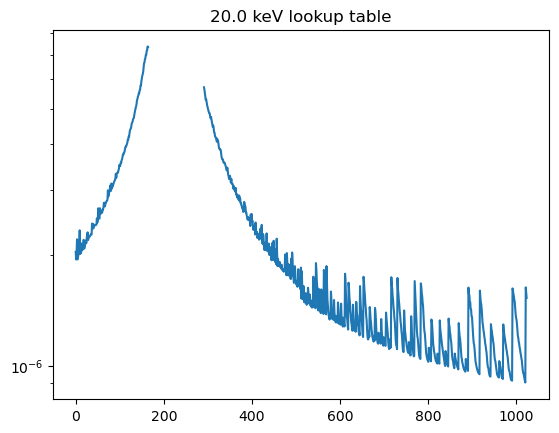

In [20]:
# Beamline input block
energy = 20000.0            # Energy in eV
energy_keV = energy/1000.0  # Energy in keV
wl = 1239.84 / (energy * 10**9)
sigmaH = (sigmaH_e**2 + wl*L_und/2/np.pi/np.pi)**0.5
sigmaV = (sigmaV_e**2 + wl*L_und/2/np.pi/np.pi)**0.5
sigmaHp = (sigmaHp_e**2 + wl/L_und/2)**0.5
sigmaVp = (sigmaVp_e**2 + wl/L_und/2)**0.5

flag_HE = True
slit1_H = 500.0e-6          # H slit size before CRL 1
slit1_V = 300.0e-6          # V slit size before CRL 1
slit2_H = 500.0e-6          # H slit size before CRL 2
slit2_V = 300.0e-6          # V slit size before CRL 2

lookup_table, L1_inF_list_sort_indices, index1to2 = Zoom_CRL2D_lookup()

plt.plot(np.linspace(0,1023,1024), lookup_table)
plt.title(str(energy_keV)+' keV lookup table')
plt.yscale('log')
plt.show()

# Comparing XS lookup table function to IOC

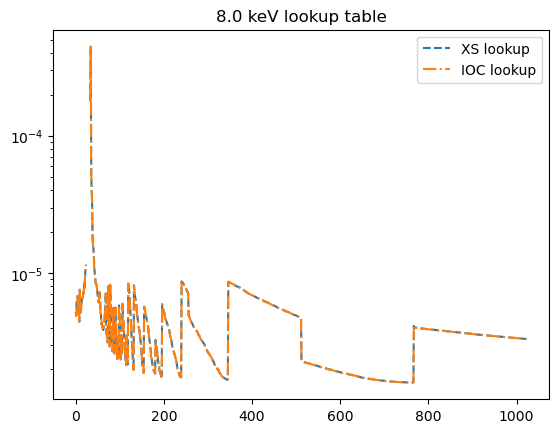

In [30]:
# Beamline input block
energy = 8000.0            # Energy in eV
energy_keV = energy/1000.0  # Energy in keV
wl = 1239.84 / (energy * 10**9)
sigmaH = (sigmaH_e**2 + wl*L_und/2/np.pi/np.pi)**0.5
sigmaV = (sigmaV_e**2 + wl*L_und/2/np.pi/np.pi)**0.5
sigmaHp = (sigmaHp_e**2 + wl/L_und/2)**0.5
sigmaVp = (sigmaVp_e**2 + wl/L_und/2)**0.5

flag_HE = True
slit1_H = 500.0e-6          # H slit size before CRL 1
slit1_V = 300.0e-6          # V slit size before CRL 1
slit2_H = 500.0e-6          # H slit size before CRL 2
slit2_V = 300.0e-6          # V slit size before CRL 2

epics.caput("100idPyCRL:testSSH1.VAL", slit1_H)
epics.caput("100idPyCRL:testSSV1.VAL", slit1_V)
epics.caput("100idPyCRL:testSSH2.VAL", slit2_H)
epics.caput("100idPyCRL:testSSV2.VAL", slit2_V)
epics.caput("100idPyCRL:CRL:thickerr_flag", flag_HE)
epics.caput("100idPyCRL:CRL:EnergySelect",0)
epics.caput("100idPyCRL:testMonoE.VAL",float(energy_keV))

lookup_table, L1_inF_list_sort_indices, index1to2 = Zoom_CRL2D_lookup()

time.sleep(1)
ioc_lookup=epics.caget("100idPyCRL:CRL:fSizes")

plt.plot(np.linspace(0,1023,1024), lookup_table, label='XS lookup', ls='--')
plt.plot(np.linspace(0,1023,1024), ioc_lookup, label='IOC lookup', ls='-.')
plt.title(str(energy_keV)+' keV lookup table')
plt.yscale('log')
plt.legend()
plt.show()

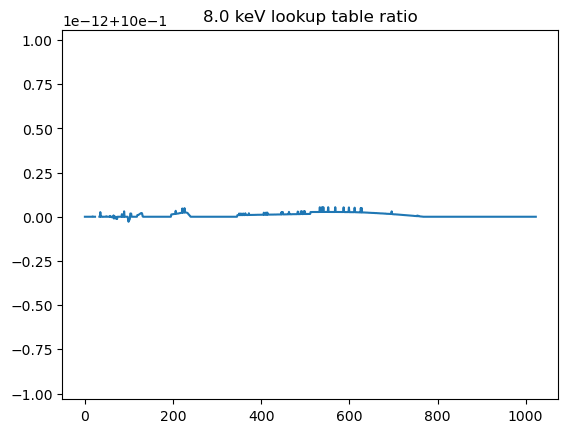

In [32]:
plt.plot(np.linspace(0,1023,1024), ioc_lookup/lookup_table)
plt.title(str(energy_keV)+' keV lookup table ratio')
plt.show()

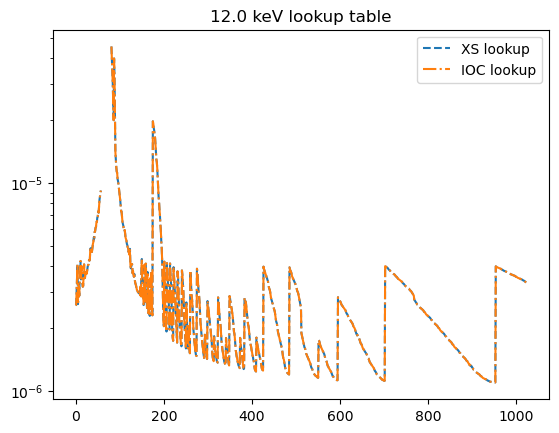

In [33]:
# Beamline input block
energy = 12000.0            # Energy in eV
energy_keV = energy/1000.0  # Energy in keV
wl = 1239.84 / (energy * 10**9)
sigmaH = (sigmaH_e**2 + wl*L_und/2/np.pi/np.pi)**0.5
sigmaV = (sigmaV_e**2 + wl*L_und/2/np.pi/np.pi)**0.5
sigmaHp = (sigmaHp_e**2 + wl/L_und/2)**0.5
sigmaVp = (sigmaVp_e**2 + wl/L_und/2)**0.5

flag_HE = True
slit1_H = 500.0e-6          # H slit size before CRL 1
slit1_V = 300.0e-6          # V slit size before CRL 1
slit2_H = 500.0e-6          # H slit size before CRL 2
slit2_V = 300.0e-6          # V slit size before CRL 2

epics.caput("100idPyCRL:testSSH1.VAL", slit1_H)
epics.caput("100idPyCRL:testSSV1.VAL", slit1_V)
epics.caput("100idPyCRL:testSSH2.VAL", slit2_H)
epics.caput("100idPyCRL:testSSV2.VAL", slit2_V)
epics.caput("100idPyCRL:CRL:thickerr_flag", flag_HE)
epics.caput("100idPyCRL:CRL:EnergySelect",0)
epics.caput("100idPyCRL:testMonoE.VAL",float(energy_keV))

lookup_table, L1_inF_list_sort_indices, index1to2 = Zoom_CRL2D_lookup()

time.sleep(1)
ioc_lookup=epics.caget("100idPyCRL:CRL:fSizes")

plt.plot(np.linspace(0,1023,1024), lookup_table, label='XS lookup', ls='--')
plt.plot(np.linspace(0,1023,1024), ioc_lookup, label='IOC lookup', ls='-.')
plt.title(str(energy_keV)+' keV lookup table')
plt.yscale('log')
plt.legend()
plt.show()

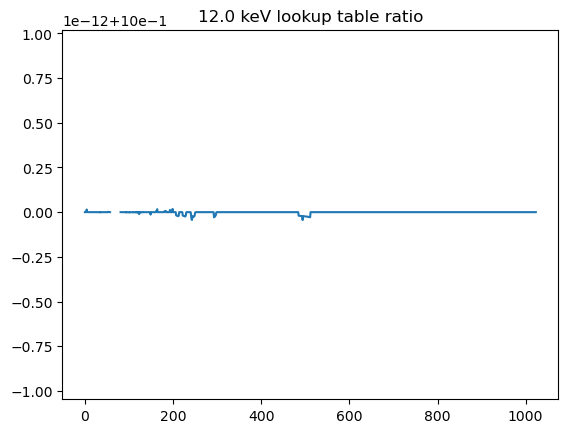

In [34]:
plt.plot(np.linspace(0,1023,1024), ioc_lookup/lookup_table)
plt.title(str(energy_keV)+' keV lookup table ratio')
plt.show()

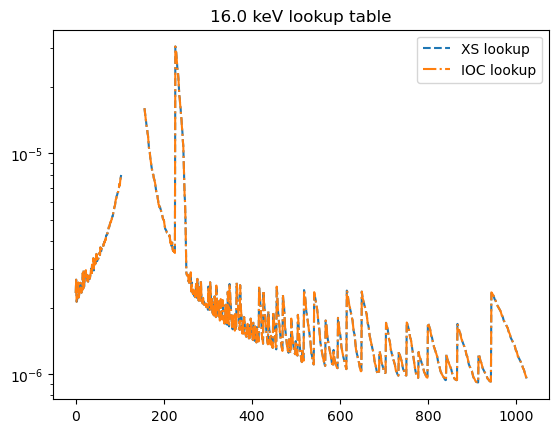

In [41]:
# Beamline input block
energy = 16000.0            # Energy in eV
energy_keV = energy/1000.0  # Energy in keV
wl = 1239.84 / (energy * 10**9)
sigmaH = (sigmaH_e**2 + wl*L_und/2/np.pi/np.pi)**0.5
sigmaV = (sigmaV_e**2 + wl*L_und/2/np.pi/np.pi)**0.5
sigmaHp = (sigmaHp_e**2 + wl/L_und/2)**0.5
sigmaVp = (sigmaVp_e**2 + wl/L_und/2)**0.5

flag_HE = True
slit1_H = 500.0e-6          # H slit size before CRL 1
slit1_V = 300.0e-6          # V slit size before CRL 1
slit2_H = 500.0e-6          # H slit size before CRL 2
slit2_V = 300.0e-6          # V slit size before CRL 2

epics.caput("100idPyCRL:testSSH1.VAL", slit1_H)
epics.caput("100idPyCRL:testSSV1.VAL", slit1_V)
epics.caput("100idPyCRL:testSSH2.VAL", slit2_H)
epics.caput("100idPyCRL:testSSV2.VAL", slit2_V)
epics.caput("100idPyCRL:CRL:thickerr_flag", flag_HE)
epics.caput("100idPyCRL:CRL:EnergySelect",0)
epics.caput("100idPyCRL:testMonoE.VAL",float(energy_keV))

lookup_table, L1_inF_list_sort_indices, index1to2 = Zoom_CRL2D_lookup()

time.sleep(1)
ioc_lookup=epics.caget("100idPyCRL:CRL:fSizes")

plt.plot(np.linspace(0,1023,1024), lookup_table, label='XS lookup', ls='--')
plt.plot(np.linspace(0,1023,1024), ioc_lookup, label='IOC lookup', ls='-.')
plt.title(str(energy_keV)+' keV lookup table')
plt.yscale('log')
plt.legend()
plt.show()

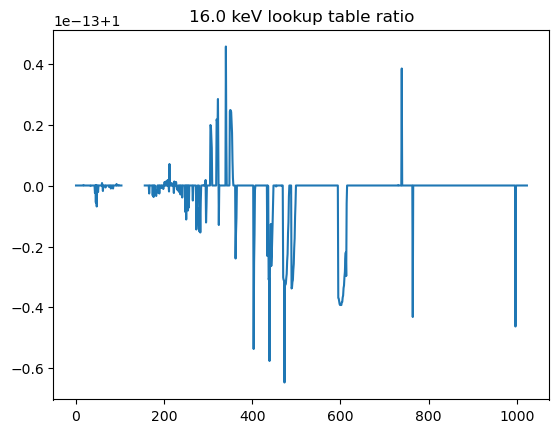

In [42]:
plt.plot(np.linspace(0,1023,1024), ioc_lookup/lookup_table)
plt.title(str(energy_keV)+' keV lookup table ratio')
plt.show()

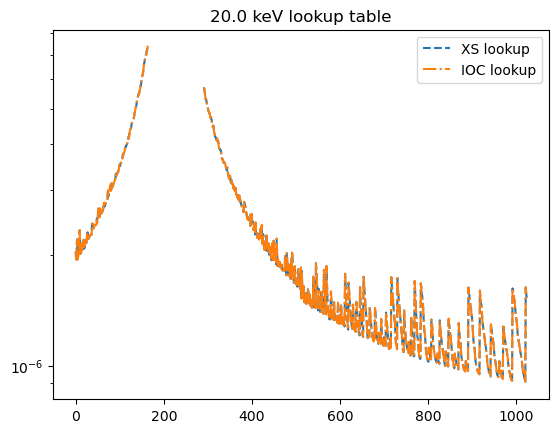

In [37]:
# Beamline input block
energy = 20000.0            # Energy in eV
energy_keV = energy/1000.0  # Energy in keV
wl = 1239.84 / (energy * 10**9)
sigmaH = (sigmaH_e**2 + wl*L_und/2/np.pi/np.pi)**0.5
sigmaV = (sigmaV_e**2 + wl*L_und/2/np.pi/np.pi)**0.5
sigmaHp = (sigmaHp_e**2 + wl/L_und/2)**0.5
sigmaVp = (sigmaVp_e**2 + wl/L_und/2)**0.5

flag_HE = True
slit1_H = 500.0e-6          # H slit size before CRL 1
slit1_V = 300.0e-6          # V slit size before CRL 1
slit2_H = 500.0e-6          # H slit size before CRL 2
slit2_V = 300.0e-6          # V slit size before CRL 2

epics.caput("100idPyCRL:testSSH1.VAL", slit1_H)
epics.caput("100idPyCRL:testSSV1.VAL", slit1_V)
epics.caput("100idPyCRL:testSSH2.VAL", slit2_H)
epics.caput("100idPyCRL:testSSV2.VAL", slit2_V)
epics.caput("100idPyCRL:CRL:thickerr_flag", flag_HE)
epics.caput("100idPyCRL:CRL:EnergySelect",0)
epics.caput("100idPyCRL:testMonoE.VAL",float(energy_keV))

lookup_table, L1_inF_list_sort_indices, index1to2 = Zoom_CRL2D_lookup()

time.sleep(1)
ioc_lookup=epics.caget("100idPyCRL:CRL:fSizes")

plt.plot(np.linspace(0,1023,1024), lookup_table, label='XS lookup', ls='--')
plt.plot(np.linspace(0,1023,1024), ioc_lookup, label='IOC lookup', ls='-.')
plt.title(str(energy_keV)+' keV lookup table')
plt.yscale('log')
plt.legend()
plt.show()

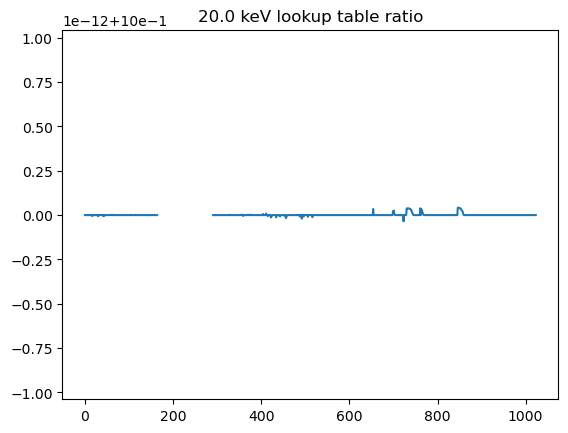

In [38]:
plt.plot(np.linspace(0,1023,1024), ioc_lookup/lookup_table)
plt.title(str(energy_keV)+' keV lookup table ratio')
plt.show()

# IOC to XS calc comparison
Testing that indexing is consistent

In [47]:
energy = 16000.0            # Energy in eV
energy_keV = energy/1000.0  # Energy in keV
wl = 1239.84 / (energy * 10**9)
sigmaH = (sigmaH_e**2 + wl*L_und/2/np.pi/np.pi)**0.5
sigmaV = (sigmaV_e**2 + wl*L_und/2/np.pi/np.pi)**0.5
sigmaHp = (sigmaHp_e**2 + wl/L_und/2)**0.5
sigmaVp = (sigmaVp_e**2 + wl/L_und/2)**0.5

flag_HE = True
slit1_H = 500.0e-6          # H slit size before CRL 1
slit1_V = 300.0e-6          # V slit size before CRL 1
slit2_H = 500.0e-6          # H slit size before CRL 2
slit2_V = 300.0e-6          # V slit size before CRL 2

epics.caput("100idPyCRL:testSSH1.VAL", slit1_H)
epics.caput("100idPyCRL:testSSV1.VAL", slit1_V)
epics.caput("100idPyCRL:testSSH2.VAL", slit2_H)
epics.caput("100idPyCRL:testSSV2.VAL", slit2_V)
epics.caput("100idPyCRL:CRL:thickerr_flag", flag_HE)
epics.caput("100idPyCRL:CRL:EnergySelect",0)
epics.caput("100idPyCRL:testMonoE.VAL",float(energy_keV))

lookup_table, L1_inF_list_sort_indices, index1to2 = Zoom_CRL2D_lookup()

time.sleep(0.5)
epics.caput("100idPyCRL:CRL:focalSize",'0.0000015')
time.sleep(0.5)
print(f'IOC actual fSize {epics.caget("100idPyCRL:CRL:fSize_actual")}')
crl1 = epics.caget("100idPyCRL:CRL:1:lenses")
crl2 = epics.caget("100idPyCRL:CRL:2:lenses")
print(f'CRL configs: {crl1} and {crl2}')
print(f'XS code fSize: {Zoom_CRL2D_focuscal(crl1, crl2)}')

IOC actual fSize 1.549050969632956e-06
CRL configs: 386 and 450
XS code fSize: 2.973983449945341e-06


Looks like things aren't lining up...

In [48]:
# Beamline input block
energy = 16000.0            # Energy in eV
energy_keV = energy/1000.0  # Energy in keV
wl = 1239.84 / (energy * 10**9)
sigmaH = (sigmaH_e**2 + wl*L_und/2/np.pi/np.pi)**0.5
sigmaV = (sigmaV_e**2 + wl*L_und/2/np.pi/np.pi)**0.5
sigmaHp = (sigmaHp_e**2 + wl/L_und/2)**0.5
sigmaVp = (sigmaVp_e**2 + wl/L_und/2)**0.5

flag_HE = True
slit1_H = 500.0e-6          # H slit size before CRL 1
slit1_V = 300.0e-6          # V slit size before CRL 1
slit2_H = 500.0e-6          # H slit size before CRL 2
slit2_V = 300.0e-6          # V slit size before CRL 2

lookup_table, L1_inF_list_sort_indices, index1to2 = Zoom_CRL2D_lookup()

In [51]:
ind = 385
print(f'{lookup_table[ind]}')
print(f'{L1_inF_list_sort_indices[ind]}')
print(f'{index1to2[ind]}')

1.549050969632956e-06
386
450


In [58]:
np.nanargmin(np.abs(np.asarray(lookup_table)-Zoom_CRL2D_focuscal(L1_inF_list_sort_indices[ind], index1to2[ind])))

38

In [56]:
np.nanargmin(np.abs(np.asarray(lookup_table)-Zoom_CRL2D_focuscal(386,450)))

38

In [57]:
lookup_table[38]

2.973753657172478e-06

In [59]:
Zoom_CRL2D_control(0.0000015)

======== Find size at focus ========================================
Energy: 16.0 keV
CRL1 configuration index in sorted list is 377
CRL1 configuration index is 377 or [1, 0, 0, 1, 1, 1, 1, 0, 1, 0]
CRL1 f is 3.08 m, focus at q1 = 3.27 m (-11.03 m from sample)
CRL2 configuration index in sorted list is 452
CRL2 configuration index is 452 or [0, 0, 1, 0, 0, 0, 1, 1, 1, 0]
CRL2 f is 2.58 m
Focal size is 1.76 μm x 1.29 μm at the focal point (7.9 mm from sample)
======== Find size at sample =======================================
CRL1 configuration index in sorted list is 385
CRL1 configuration index is 386 or [0, 1, 0, 0, 0, 0, 0, 1, 1, 0]
CRL1 f is 3.01 m, focus at q1 = 3.20 m (-11.10 m from sample)
CRL2 configuration index in sorted list is 450
CRL2 configuration index is 451 or [1, 1, 0, 0, 0, 0, 1, 1, 1, 0]
CRL2 f is 2.59 m
Beam size is 1.81 μm x 1.32 μm at the sample position)


Matching "control" but not focuscal?

In [60]:
Zoom_CRL2D_focuscal(386, 451)

1.549050969632956e-06

Not quite --> looks like IOC is reporting 10-bit config for CRL1 but sorted index for CRL2 --> correct needed to index sorted_invF_index['2'] with index1to2_sorted[indexSorted] to get lens configuration

In [68]:
energy = 16000.0            # Energy in eV
energy_keV = energy/1000.0  # Energy in keV
wl = 1239.84 / (energy * 10**9)
sigmaH = (sigmaH_e**2 + wl*L_und/2/np.pi/np.pi)**0.5
sigmaV = (sigmaV_e**2 + wl*L_und/2/np.pi/np.pi)**0.5
sigmaHp = (sigmaHp_e**2 + wl/L_und/2)**0.5
sigmaVp = (sigmaVp_e**2 + wl/L_und/2)**0.5

flag_HE = True
slit1_H = 500.0e-6          # H slit size before CRL 1
slit1_V = 300.0e-6          # V slit size before CRL 1
slit2_H = 500.0e-6          # H slit size before CRL 2
slit2_V = 300.0e-6          # V slit size before CRL 2

epics.caput("100idPyCRL:testSSH1.VAL", slit1_H)
epics.caput("100idPyCRL:testSSV1.VAL", slit1_V)
epics.caput("100idPyCRL:testSSH2.VAL", slit2_H)
epics.caput("100idPyCRL:testSSV2.VAL", slit2_V)
epics.caput("100idPyCRL:CRL:thickerr_flag", flag_HE)
epics.caput("100idPyCRL:CRL:EnergySelect",0)
epics.caput("100idPyCRL:testMonoE.VAL",float(energy_keV))

lookup_table, L1_inF_list_sort_indices, index1to2 = Zoom_CRL2D_lookup()

time.sleep(0.5)
epics.caput("100idPyCRL:CRL:focalSize",'0.000008')
time.sleep(0.5)
print(f'IOC actual fSize {epics.caget("100idPyCRL:CRL:fSize_actual")}')
crl1 = epics.caget("100idPyCRL:CRL:1:lenses")
crl2 = epics.caget("100idPyCRL:CRL:2:lenses")
print(f'CRL configs: {crl1} and {crl2}')
print(f'XS code fSize: {Zoom_CRL2D_focuscal(crl1, crl2)}')

IOC actual fSize 8.016234618405476e-06
CRL configs: 178 and 698
XS code fSize: 8.016234618405506e-06


In [69]:
Zoom_CRL2D_control(0.000008)

======== Find size at focus ========================================
Energy: 16.0 keV
CRL1 configuration index in sorted list is 175
CRL1 configuration index is 173 or [1, 0, 1, 1, 0, 1, 0, 1, 0, 0]
CRL1 f is 6.66 m, focus at q1 = 7.65 m (-6.65 m from sample)
CRL2 configuration index in sorted list is 704
CRL2 configuration index is 706 or [0, 1, 0, 0, 0, 0, 1, 1, 0, 1]
CRL2 f is 1.57 m
Focal size is 10.80 μm x 6.02 μm at the focal point (10.6 mm from sample)
======== Find size at sample =======================================
CRL1 configuration index in sorted list is 176
CRL1 configuration index is 178 or [0, 1, 0, 0, 1, 1, 0, 1, 0, 0]
CRL1 f is 6.65 m, focus at q1 = 7.62 m (-6.68 m from sample)
CRL2 configuration index in sorted list is 698
CRL2 configuration index is 698 or [0, 1, 0, 1, 1, 1, 0, 1, 0, 1]
CRL2 f is 1.59 m
Beam size is 10.72 μm x 5.99 μm at the sample position)


much better...

# What next?

Check that off-lookup-table moves match up

In [71]:
crl1 = epics.caget("100idPyCRL:CRL:1:lenses")
crl2 = epics.caget("100idPyCRL:CRL:2:lenses")
fSize = epics.caget("100idPyCRL:CRL:fSize_actual")
print(f'For configs: {crl1} and {crl2}, IOC yeilds {fSize} focal size')
print(f'XS code fSize: {Zoom_CRL2D_focuscal(crl1, crl2)}')

For configs: 178 and 704, IOC yeilds 7.839122984830116e-06 focal size
XS code fSize: 7.839122984830116e-06


In [72]:
crl1 = epics.caget("100idPyCRL:CRL:1:lenses")
crl2 = epics.caget("100idPyCRL:CRL:2:lenses")
fSize = epics.caget("100idPyCRL:CRL:fSize_actual")
print(f'For configs: {crl1} and {crl2}, IOC yeilds {fSize} focal size')
print(f'XS code fSize: {Zoom_CRL2D_focuscal(crl1, crl2)}')

For configs: 222 and 518, IOC yeilds 8.177871564000929e-06 focal size
XS code fSize: 8.177871564000929e-06
